In [20]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from anngeno import AnnGeno
# pl.Config.set_tbl_rows(15)

In [21]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)

config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Read the variant consequence configuration
records = []
for group, consequences in config["variant_consequences"].items():
    for consequence in consequences:
        records.append({'variant_class': group, 'vep_consequence': consequence})
var_cons = pl.DataFrame(records)


# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""score_pai3d""","""#feb72d""","""PrimateAI-3D""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
…,…,…,…,…
"""splicing""","""absplice_dna_max""","""#28a745""","""AbSplice (max)""",1
"""splicing""","""absplice2_max""","""#28a745""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1


In [22]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass394genes_olink371genes_annotated_MANE_CADD_251110.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# existing_annos = ['cadd_raw', 'gpn_score', 'gpn_star_llr_calibrated_mean']
# existing_annos = ['am_pathogenicity']

# Filter variant classes
variant_class = "non_coding"
consequences_for_group = var_cons.filter(
    pl.col('variant_class') == variant_class
)['vep_consequence'].to_list()
filter_expression = pl.any_horizontal(
    (pl.col(c) == 1) for c in consequences_for_group if c in anno.collect_schema().names()
)

# min_range = -500
# max_range = +0

anno = (
    anno
    .filter(
        # (pl.col('vep_cds') == False) &
        # (pl.col('mane_cds') == False) &
        # (pl.col('non_mane_cds') == False) &
        
        # filter_expression &
        # (
        #     (pl.col('consequence_splice_donor_variant') == 0) &
        #     (pl.col('consequence_splice_acceptor_variant') == 0) &
        #     (pl.col('consequence_splice_region_variant') == 0) &
        #     (pl.col('consequence_splice_donor_5th_base_variant') == 0) &
        #     (pl.col('consequence_splice_donor_region_variant') == 0) &
        #     (pl.col('consequence_splice_polypyrimidine_tract_variant') == 0)
        # ) &
        # (
        #     (pl.col('consequence_splice_donor_variant') == 0) &
        #     (pl.col('consequence_splice_acceptor_variant') == 0)
        #     (pl.col('consequence_start_retained_variant') == 0) &
        #     (pl.col('consequence_start_lost') == 0)
        # ) &
        
        # Distance to TSS range
        # (pl.col('dist_to_tss') >= min_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'tss', 'strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

loftee_hc,dist_to_tss,gpn_score,pangolin_score,tss,gene_length,id,gene_name,am_pathogenicity,strand,mamphylop,cadd_raw,region,delta_score,score_pai3d,absplice_dna_max,esmscoremissense,promoterai,absplice2_max,verphylop,gpn_star_llr_calibrated_mean
i8,i64,f32,f64,i64,i64,str,str,f32,str,f32,f32,str,f64,f32,f64,f32,f32,f64,f32,f32
0,57135,0.9,0.0,158686715,76013,"""chr1:158629580:T:C""","""SPTA1""",null,"""-1""",-1.301,-0.283735,"""ENSG00000163554""",0.0,null,0.001,null,null,0.000033,-1.395,1.896398
0,68443,-1.31,0.0,158686715,76013,"""chr1:158618272:G:A""","""SPTA1""",null,"""-1""",1.346,0.665707,"""ENSG00000163554""",0.0,null,0.001,null,null,0.000033,1.209,-0.285355
0,68287,-0.86,0.0,158686715,76013,"""chr1:158618428:C:T""","""SPTA1""",null,"""-1""",-0.322,0.329809,"""ENSG00000163554""",0.0,null,0.001,null,null,0.000033,-0.297,-0.573519
0,64266,-1.46,0.0,158686715,76013,"""chr1:158622449:T:G""","""SPTA1""",null,"""-1""",0.306,0.390204,"""ENSG00000163554""",0.0,null,0.001,null,null,0.000033,0.323,-0.520327
0,62297,-0.04,0.0,158686715,76013,"""chr1:158624418:C:T""","""SPTA1""",null,"""-1""",0.063,0.616764,"""ENSG00000163554""",0.0,null,0.001,null,null,0.000033,0.063,0.896379
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,47663,-8.25,null,127854658,39647,"""chr9:127806995:C:T""","""ENG""",null,"""-1""",null,5.824879,"""ENSG00000106991""",null,null,null,null,null,null,null,-8.998302
0,48132,-1.33,null,127854658,39647,"""chr9:127806526:T:C""","""ENG""",null,"""-1""",null,-0.084201,"""ENSG00000106991""",null,null,null,null,null,null,null,-0.184873
0,45640,-4.25,null,127854658,39647,"""chr9:127809018:G:C""","""ENG""",null,"""-1""",null,1.129233,"""ENSG00000106991""",null,null,null,null,null,null,null,-1.882955


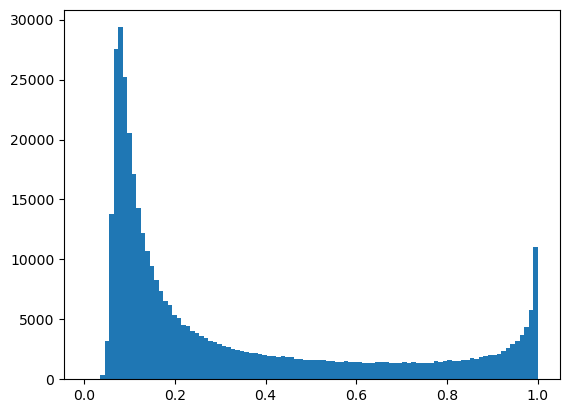

In [23]:
plt.hist(anno['am_pathogenicity'].drop_nulls(), bins=100)
plt.show()

In [24]:
melted_anno = (
    anno.unpivot(
        index=["id", "region"],
        on=existing_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df,
        on="annotation",
        how="left"
    )

    .filter(
        # Remove null annotation scores
        (pl.col('annotation_score').is_not_null()) &

        # Filter based on category
        pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation', 'missense'])
        # (pl.col('category').is_in(['genetic_diversity', 'splicing', 'conservation']))
    )

    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank = pl.col('annotation_score_dircor').rank(method="average").over(["region", "annotation"]).cast(pl.Float32),
        anno_score_count = pl.len().over(["region", "annotation"]).cast(pl.Int32)
    )
    .with_columns(
        annotation_score_dircor_ptile = pl.col('annotation_score_dircor_rank') / pl.col('anno_score_count').round(4).cast(pl.Float32)
    )
    .drop(['anno_score_count', 'annotation_score_dircor'])
)

melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor_rank,annotation_score_dircor_ptile
str,str,str,f32,str,str,str,i8,f32,f32
"""chr1:158647693:G:A""","""ENSG00000163554""","""am_pathogenicity""",0.1245,"""missense""","""#feb72d""","""AlphaMissense""",1,786.5,0.380687
"""chr1:158612895:C:G""","""ENSG00000163554""","""am_pathogenicity""",0.4223,"""missense""","""#feb72d""","""AlphaMissense""",1,1704.0,0.824782
"""chr1:158618054:G:T""","""ENSG00000163554""","""am_pathogenicity""",0.1255,"""missense""","""#feb72d""","""AlphaMissense""",1,800.0,0.387222
"""chr1:158635989:C:T""","""ENSG00000163554""","""am_pathogenicity""",0.1623,"""missense""","""#feb72d""","""AlphaMissense""",1,1080.5,0.522991
"""chr1:158648513:T:C""","""ENSG00000163554""","""am_pathogenicity""",0.104,"""missense""","""#feb72d""","""AlphaMissense""",1,538.5,0.260649
…,…,…,…,…,…,…,…,…,…
"""chr10:116115980:C:T""","""ENSG00000151892""","""absplice2_max""",0.000034,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,69186.0,0.873903
"""chr10:116104870:T:A""","""ENSG00000151892""","""absplice2_max""",0.000033,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,33297.5,0.420588
"""chr10:116109612:G:A""","""ENSG00000151892""","""absplice2_max""",0.000033,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,33297.5,0.420588


In [25]:
ptile_counts_df = (
    melted_anno
    .group_by(['annotation', 'annotation_score_dircor_ptile'])
    .agg(
        n_vars_at_ptile = pl.len()
    )
    .sort('annotation_score_dircor_ptile', descending=True)
    .with_columns(
        n_vars_above_ptile = pl.col('n_vars_at_ptile').cum_sum().over('annotation')
    )
)

melted_anno = melted_anno.join(ptile_counts_df, on=['annotation', 'annotation_score_dircor_ptile'], how='inner')
melted_anno

id,region,annotation,annotation_score,category,color,label,annotation_dir,annotation_score_dircor_rank,annotation_score_dircor_ptile,n_vars_at_ptile,n_vars_above_ptile
str,str,str,f32,str,str,str,i8,f32,f32,u64,u64
"""chr1:158647693:G:A""","""ENSG00000163554""","""am_pathogenicity""",0.1245,"""missense""","""#feb72d""","""AlphaMissense""",1,786.5,0.380687,2,246690
"""chr1:158612895:C:G""","""ENSG00000163554""","""am_pathogenicity""",0.4223,"""missense""","""#feb72d""","""AlphaMissense""",1,1704.0,0.824782,1,70009
"""chr1:158618054:G:T""","""ENSG00000163554""","""am_pathogenicity""",0.1255,"""missense""","""#feb72d""","""AlphaMissense""",1,800.0,0.387222,3,244081
"""chr1:158635989:C:T""","""ENSG00000163554""","""am_pathogenicity""",0.1623,"""missense""","""#feb72d""","""AlphaMissense""",1,1080.5,0.522991,4,190066
"""chr1:158648513:T:C""","""ENSG00000163554""","""am_pathogenicity""",0.104,"""missense""","""#feb72d""","""AlphaMissense""",1,538.5,0.260649,2,294427
…,…,…,…,…,…,…,…,…,…,…,…
"""chr10:116115980:C:T""","""ENSG00000151892""","""absplice2_max""",0.000034,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,69186.0,0.873903,5139,2055769
"""chr10:116104870:T:A""","""ENSG00000151892""","""absplice2_max""",0.000033,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,33297.5,0.420588,66594,7268652
"""chr10:116109612:G:A""","""ENSG00000151892""","""absplice2_max""",0.000033,"""splicing""","""#28a745""","""AbSplice2 (max)""",1,33297.5,0.420588,66594,7268652


In [26]:
ct_df = melted_anno.group_by('annotation').agg(
    n_vars = pl.len(),
    max_ptile = pl.col('annotation_score_dircor_ptile').max(),
).sort('n_vars', descending=True)

assert ct_df['max_ptile'].min() == 1.0
ct_df

annotation,n_vars,max_ptile
str,u64,f32
"""gpn_star_llr_calibrated_mean""",22836028,1.0
"""gpn_score""",22836028,1.0
"""cadd_raw""",22836028,1.0
"""verphylop""",22695025,1.0
"""mamphylop""",22695025,1.0
…,…,…
"""absplice_dna_max""",14485444,1.0
"""delta_score""",14354897,1.0
"""esmscoremissense""",432598,1.0


In [27]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
        .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value_ptile', 'n_individuals']
    )
)

# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [28]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)

# gene_trait_df = gene_trait_df.head()
gene_trait_df = gene_trait_df.filter(
    pl.col('gene_name') == "LDLR",
    # pl.col('phenotype') == "ldl_direct_int",
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000130164""","""LDLR""","""ldl_direct_int""",0.037908,12461,0.707871,4.1162e-11,1.0
"""ENSG00000130164""","""LDLR""","""cholesterol_int""",0.034494,12473,0.544121,2.2820e-7,1.0
"""ENSG00000130164""","""LDLR""","""apolipoprotein_b_int""",0.036808,12426,0.731293,4.1419e-11,1.0


## Odds ratio computation

In [29]:
n_steps = 100
min_rank_cutoff = 10_000
max_rank_cutoff = 1_000_000
or_threshold_pheno = 0.99

# cutoffs_list = np.geomspace(
cutoffs_list = np.linspace(
    min_rank_cutoff, 
    max_rank_cutoff, 
    num=n_steps
).tolist()

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": cutoffs_list})

len(cutoffs_list)

100

In [30]:
# --- 1. Lazily prepare the filter keys ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())


# --- Build main query (same as before, but stop before group_by) ---
gp_lazy = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_nan' in c]), 
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor_ptile = pl.when(pl.col('corr_dir') == -1)
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

# Cross join with cutoffs and compute odds ratios
or_lazy = (
    gp_lazy
    .select(["annotation", "region", "gene_name", "phenotype", "n_vars_above_ptile", "mean_pheno_value_dircor_ptile"])
    .join(cutoffs_lazy, how="cross")
    .group_by(["annotation", "region", "gene_name", "phenotype", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("n_vars_above_ptile") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("n_vars_above_ptile") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("n_vars_above_ptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("n_vars_above_ptile") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_dircor_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        # odds_ratio = ((pl.col("n_dis_above_cutoff") + 1) / (pl.col("n_notdis_above_cutoff")+1)) / (1 - or_threshold_pheno)
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff')

or_df.write_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_rank_cutoffs_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

or_df

Executing with odds ratios...


annotation,region,gene_name,phenotype,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,str,f64,u64,u64,u64,u64,f64
"""gpn_star_llr_calibrated_mean""","""ENSG00000130164""","""LDLR""","""apolipoprotein_b_int""",10000.0,1,7,156,12262,11.228938
"""absplice_dna_max""","""ENSG00000130164""","""LDLR""","""apolipoprotein_b_int""",10000.0,0,7,133,9428,0.0
"""am_pathogenicity""","""ENSG00000130164""","""LDLR""","""cholesterol_int""",10000.0,2,11,19,427,4.086124
"""cadd_raw""","""ENSG00000130164""","""LDLR""","""ldl_direct_int""",10000.0,1,6,154,12300,13.311688
"""cadd_raw""","""ENSG00000130164""","""LDLR""","""cholesterol_int""",10000.0,1,6,148,12318,13.871622
…,…,…,…,…,…,…,…,…,…
"""gpn_score""","""ENSG00000130164""","""LDLR""","""apolipoprotein_b_int""",1e6,26,497,131,11772,4.701061
"""cadd_raw""","""ENSG00000130164""","""LDLR""","""apolipoprotein_b_int""",1e6,26,536,131,11733,4.344565
"""gpn_star_llr_calibrated_mean""","""ENSG00000130164""","""LDLR""","""cholesterol_int""",1e6,24,531,125,11793,4.264136


In [31]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
    )
    .with_columns(
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'rank_cutoff', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label']),
        on='annotation',
        how='left'
    )
    .sort('rank_cutoff')
)

plt_df

unique percentile cutoffs: 100


annotation,rank_cutoff,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label
str,f64,u64,f64,f64,f64,f64,f64,str,str
"""cadd_raw""",10000.0,3,13.311688,13.428269,0.229831,13.878737,12.9778,"""#1f77b4""","""CADD Raw"""
"""gpn_star_llr_calibrated_mean""",10000.0,3,0.0,3.742979,3.742979,11.079219,-3.59326,"""#942c80""","""GPN-Star"""
"""esmscoremissense""",10000.0,3,6.481203,5.949575,0.66003,7.243234,4.655915,"""#feb72d""","""ESM1v"""
"""score_pai3d""",10000.0,3,2.383333,2.169819,0.220751,2.60249,1.737147,"""#feb72d""","""PrimateAI-3D"""
"""absplice2_max""",10000.0,3,0.0,0.0,0.0,0.0,0.0,"""#28a745""","""AbSplice2 (max)"""
…,…,…,…,…,…,…,…,…,…
"""absplice_dna_max""",1e6,3,2.100301,2.036579,0.113002,2.258063,1.815094,"""#28a745""","""AbSplice (max)"""
"""gpn_star_llr_calibrated_mean""",1e6,3,4.45749,4.784678,0.427525,5.622627,3.94673,"""#942c80""","""GPN-Star"""
"""gpn_score""",1e6,3,4.701061,4.885004,0.422153,5.712424,4.057583,"""#942c80""","""GPN-MSA"""


## Plotting

/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10


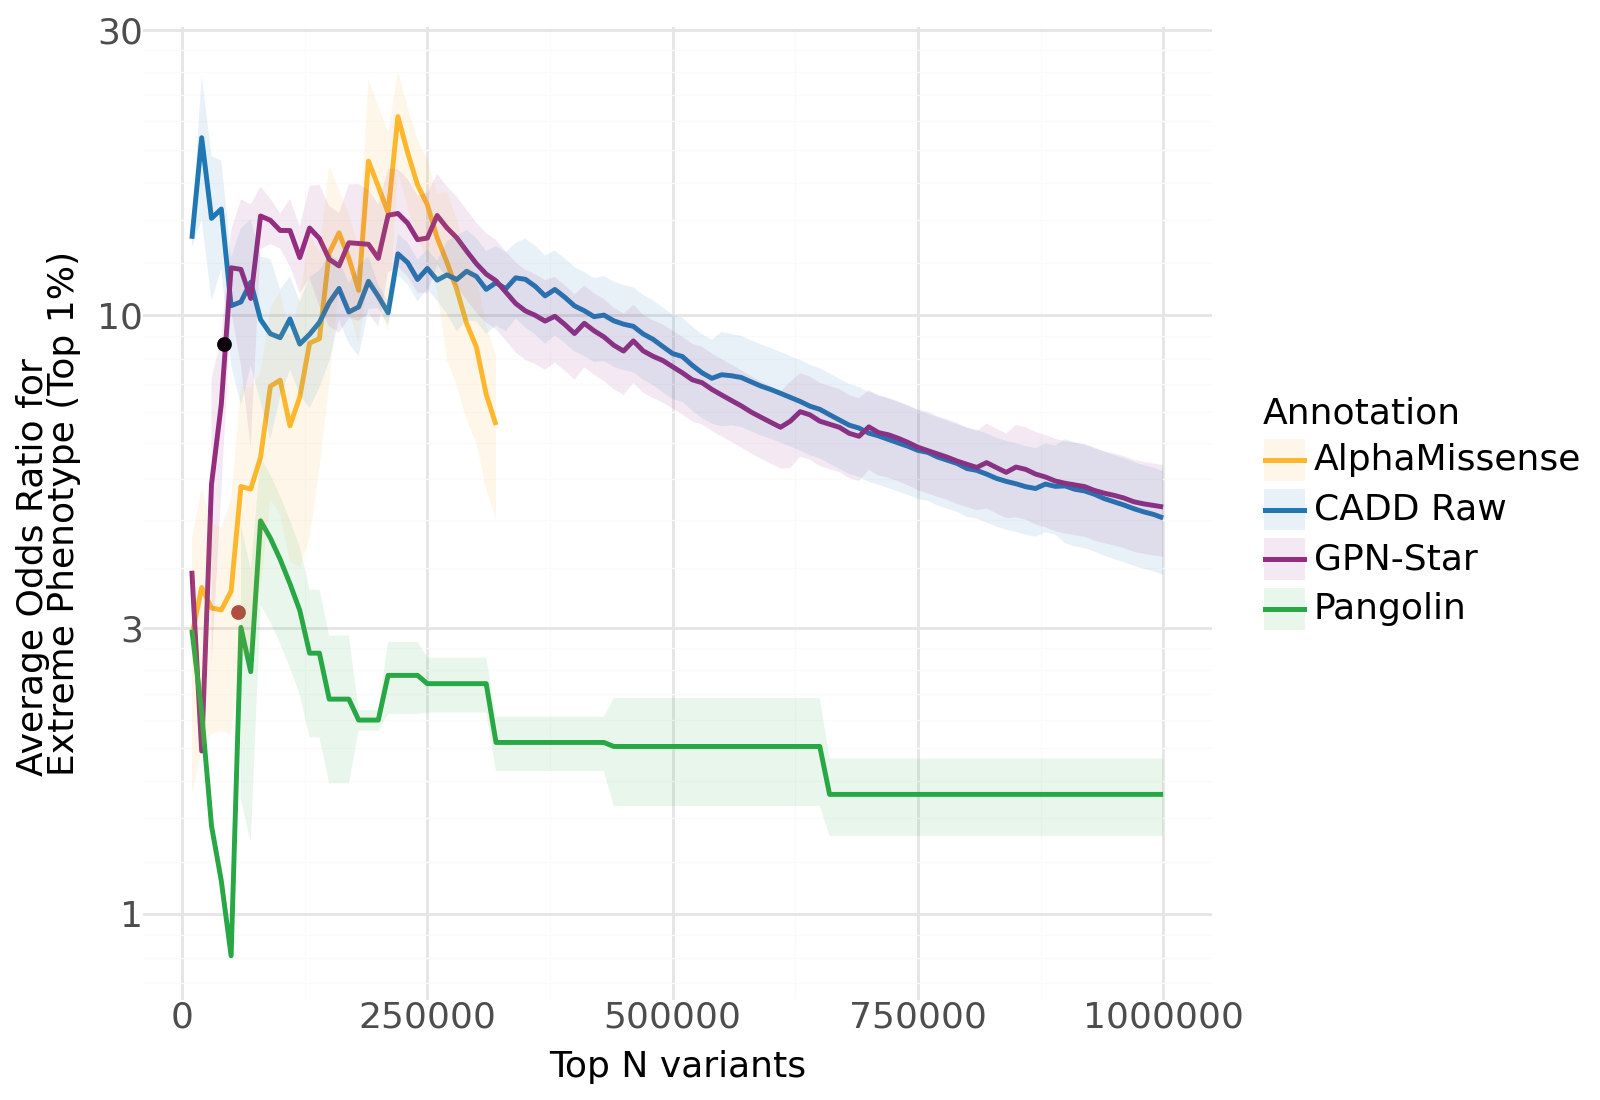

In [ ]:
color_dict = dict(zip(plt_df['label'], plt_df['color']))

# am_lof_df = pl.DataFrame({
#     'annotation': ['loftee_coding', 'am_0.8_coding'],
#     'n_vars': [21519, 56609],
#     'mean_or': [6.874422, 2.323273],
#     'median_or': [3.04127, 1.770242],
# })

am_lof_df = pl.DataFrame({
    'annotation': ['loftee_coding', 'am_0.8_coding'],
    'n_vars': [43179, 57191],
    'mean_or': [8.963194, 3.196688],
    'median_or': [3.724961, 1.955789],
})

(
    ggplot(
        # plt_df,
        plt_df.filter(pl.col('annotation').is_in(['cadd_raw', 'gpn_star_llr_calibrated_mean', 'pangolin_score', 'am_pathogenicity'])),
        aes(x='rank_cutoff', y='avg_odds_ratio')
    )
    + geom_line(aes(color='label'), size=1)
    + geom_point(am_lof_df.filter(pl.col('annotation')=='loftee_coding'), aes(x='n_vars', y='mean_or'), color='black', size=2)
    + geom_point(am_lof_df.filter(pl.col('annotation')=='am_0.8_coding'), aes(x='n_vars', y='mean_or'), color='#AA4344', size=2)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        y="Average Odds Ratio for\nExtreme Phenotype (Top 1%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    # + scale_x_log10()
    + scale_y_log10()
    + theme_minimal()
    + theme(
        figure_size=(8, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
    )
)